In [1]:
import os
import ast

if 'PATH_SET' not in locals():
    os.chdir('../..')
    PATH_SET = True
    
import torch    

if 'THREADS_SET' not in locals():
    try:
        os.environ['OMP_NUM_THREADS'] = '1'
        os.environ['MKL_NUM_THREADS'] = '1'
        
        torch.set_num_threads(1)
        torch.set_num_interop_threads(1)
        THREADS_SET = True
    except:
        pass

import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle')

In [2]:
from helpers.geographic_setup import (
    design_space_shoulder,
    events_shoulder,
    picking_stats_shoulder,
    topo_data,
)

from helpers.helper_functions import concave_hull2D_prior_dist_constructor
from helpers.likelihood import DataLikelihood
from helpers.forward import TTLookup

In [3]:
vp_model_shoulder = xr.load_dataarray(
    'data/velocity_model/3d_model_final/vp_xarray.nc',
    engine='netcdf4',
    format='NETCDF4'
    )

In [4]:
SHOULDER_E_MIN = vp_model_shoulder['easting'].values.min()
SHOULDER_E_MAX = vp_model_shoulder['easting'].values.max()
SHOULDER_N_MIN = vp_model_shoulder['northing'].values.min()
SHOULDER_N_MAX = vp_model_shoulder['northing'].values.max()

dx = 10

topo_data = topo_data.interp(
    easting=np.arange(SHOULDER_E_MIN, SHOULDER_E_MAX, dx),
    northing=np.arange(SHOULDER_N_MIN, SHOULDER_N_MAX, dx),
)

z = torch.from_numpy(topo_data.values).float()

x_posterior = torch.arange(
    topo_data['easting'].values.min()+dx, topo_data['easting'].values.max()-dx, dx)
y_posterior = torch.arange(
    topo_data['northing'].values.min()+dx, topo_data['northing'].values.max()-dx, dx)
z_posterior = torch.from_numpy(
    topo_data.interp(easting=x_posterior, northing=y_posterior).values)

print(f'Posterior x: {x_posterior.min()} - {x_posterior.max()} ({x_posterior.shape[0]} points)')
print(f'Posterior y: {y_posterior.min()} - {y_posterior.max()} ({y_posterior.shape[0]} points)')
print(f'Posterior z: {z_posterior.min()} - {z_posterior.max()}')

Posterior x: 521.5400390625 - 1901.5400390625 (139 points)
Posterior y: 1141.6800537109375 - 1581.6800537109375 (45 points)
Posterior z: 1935.4761669621366 - 2352.0121661516464


In [5]:
X_posterior, Y_posterior = torch.meshgrid(
    x_posterior, y_posterior, indexing='ij')    

indices = torch.arange(z_posterior.numel())
posterior_grid = torch.stack(
    [X_posterior.ravel(), Y_posterior.ravel(),
     z_posterior.ravel(), indices], dim=-1)

torch.save(posterior_grid, 'data/priors/shoulder_posterior_grid.pt')

In [6]:
prior_dist = concave_hull2D_prior_dist_constructor(
    design_space_shoulder[..., :2],
    topo_data,
    buffer=0.0,
    depth=10.0,
    ratio=0.1,
)

In [7]:
lookup_data = torch.load('data/data_lookup/heterogeneous_shoulder_posterior.pt')

forward_function_heterogenous =  TTLookup(
    posterior_grid, design_space_shoulder, lookup_data,
)

forward_function_shots =  TTLookup(
    events_shoulder, design_space_shoulder,
    torch.load('data/data_lookup/heterogeneous_shoulder_shots.pt'),
)

data_likelihood = DataLikelihood(
    forward_function=forward_function_heterogenous,
    dependence_distance=150,
    vel_sigma=0.05,
    tt_obs_std=0.01,
)

In [8]:
data_likelihood = DataLikelihood(
    forward_function=forward_function_heterogenous,
    dependence_distance=0,
    vel_sigma=0.05,
    tt_obs_std=0.01,
)

In [9]:
design_df = pd.read_csv('generate_designs/data/design_data.csv')
design_df = design_df[design_df['study_area'] == 'shoulder']
design_df = design_df.reset_index(drop=True)

print(f'Number of designs: {len(design_df)}')
print(f'Number of events : {len(events_shoulder)}')

Number of designs: 2226
Number of events : 94


In [10]:
design_df['N_rec'].max()

np.int64(50)

In [11]:
import numpy as np

design_space_shoulder_clean = design_space_shoulder.clone()
# Remove indices_shoulder
faulty_indices = [245, 98, 165, 218, 219]
# Create a mask for indices NOT in faulty_indices
mask = ~torch.isin(design_space_shoulder_clean[:, 3], torch.tensor(faulty_indices, dtype=design_space_shoulder_clean.dtype))
design_space_shoulder_clean = design_space_shoulder_clean[mask]

design_df = design_df.copy()

for idx, row in design_df.iterrows():
    design = np.array(ast.literal_eval(row['design']))
    # Check if any design point has a faulty index
    needs_fixing = False
    for i, design_point in enumerate(design):
        if len(design_point) >= 4 and design_point[3] in faulty_indices:
            needs_fixing = True
        
            # print(f"Faulty index {design_point} found in design at row {idx}, point {i}")
        
            # If it has a faulty index, replace it with the closest point in design_space_shoulder    
            # Find closest point in design_space_shoulder based on first 3 coordinates
            distances = torch.cdist(
                torch.tensor(design_point[:3]).unsqueeze(0).float(),
                design_space_shoulder_clean[:, :3].float()
            )
            closest_idx = distances.argmin().item()
            design[i] = design_space_shoulder_clean[closest_idx].tolist()
    
    # Update the design if any fixes were made
    if needs_fixing:
        design_df.at[idx, 'design'] = str(design.tolist())
        # print(f"Fixed design at row {idx}")

In [12]:
tt_obs_file = 'data/picking_stats/shoulder_tt_obs.pt'

if not os.path.exists(tt_obs_file):
    tt_obs_collection = torch.full((len(events_shoulder), len(design_space_shoulder)), torch.nan)
    print(f'Number of TTs: {tt_obs_collection.numel()}')

    for d_i, design in tqdm(enumerate(design_space_shoulder), total=len(design_space_shoulder)):
        for e_i, event in enumerate(events_shoulder):
            try:
                tt_obs_collection[e_i, d_i] = picking_stats_shoulder[(
                    (picking_stats_shoulder['src_name'] == f'{event[0].item():4.0f}_{event[1].item():4.0f}') &
                    (picking_stats_shoulder['rec_name'] == f'{design[0].item():4.0f}_{design[1].item():4.0f}')
                )]['tt'].values[0]
            except:
                pass
    torch.save(tt_obs_collection, tt_obs_file)
else:
    tt_obs_collection = torch.load(tt_obs_file)


In [13]:
design_space_shoulder.shape

torch.Size([375, 4])

In [14]:
def is_scenario_in_design_data(design_data, scen):
    
    design_data = pd.DataFrame(design_data, columns=summary_statistics.columns)
    
    out =  ((design_data['study_area'] == scen['study_area']) &
            (design_data['model_prior'] == scen['model_prior']) &
            (design_data['velocity_model'] == scen['velocity_model']) &
            (design_data['vel_sigma'] == scen['vel_sigma']) &
            (design_data['noise_correlation'] == scen['noise_correlation']) &
            (design_data['drop_mean'] == scen['drop_mean']) &
            (design_data['drop_gradient'] == scen['drop_gradient']) &
            (design_data['optimisation'] == scen['optimisation']) &
            (design_data['EIG_method'] == scen['EIG_method']) &
            (design_data['EIG_N'] == scen['EIG_N']) &
            (design_data['N_rec'] == scen['N_rec'])).any()
    return out


In [15]:
with torch.no_grad():
    log_p_prior_original = prior_dist.log_prob(posterior_grid, fast_eval=False)
    log_p_prior_original = log_p_prior_original.reshape(X_posterior.shape)

p_prior = log_p_prior_original.exp()
p_prior = p_prior / torch.nansum(p_prior) # for some reason prior is not normalized, do it here

prior_mask = log_p_prior_original.isfinite()

log_p_prior = p_prior.log()
log_p_prior[~prior_mask] = torch.nan

In [16]:
# Compute grid spacings
dx_val = float(dx)
dy_val = float(dx)

grid_volume = dx_val * dy_val
entropy_correction = np.log(grid_volume)

In [17]:
design_df[design_df.N_rec >= 30].iloc[1].design

'[[569.0960083007812, 1451.989990234375, 2142.342041015625, 121.0], [1365.4859619140625, 1363.197021484375, 2228.14306640625, 279.0], [1391.6309814453125, 1552.10302734375, 2300.785888671875, 19.0], [794.5059814453125, 1401.93896484375, 2209.717041015625, 196.0], [1537.2740478515625, 1463.926025390625, 2302.47607421875, 155.0], [1547.8079833984375, 1485.85205078125, 2312.6279296875, 120.0], [1435.70703125, 1435.821044921875, 2270.9951171875, 185.0], [1504.06396484375, 1556.7559814453125, 2339.60888671875, 23.0], [648.0980224609375, 1543.39794921875, 2206.0830078125, 3.0], [1546.98095703125, 1534.0389404296875, 2331.339111328125, 51.0], [561.5390014648438, 1542.1800537109375, 2189.761962890625, 0.0], [1093.0030517578125, 1430.72802734375, 2261.990966796875, 173.0], [953.6439819335938, 1284.7330322265625, 2204.702880859375, 353.0], [1376.3289794921875, 1484.14501953125, 2276.5009765625, 114.0], [1504.06396484375, 1556.7559814453125, 2339.60888671875, 23.0], [1238.072021484375, 1289.45202

In [18]:
summary_file = 'benchmark_designs/shoulder/data/summary_statistics.csv'

if os.path.exists(summary_file):
    summary_statistics = pd.read_csv(summary_file)
else:
    summary_statistics = pd.DataFrame(
        columns=[
            'study_area', 'model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
            'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N', 'N_rec', 
            'design',
            'mean_x', 'mean_y', 'std_x', 'std_y', 
            'distance_mean', 'distance_map',
            'p_posterior', 'posterior_entropy', 'posterior_information',
            'prior_entropy', 'prior_information', 'event', 'event_index'
        ]
    )
    summary_statistics.to_csv('benchmark_designs/shoulder/data/summary_statistics.csv', index=False)
    
    for d_i, scen in tqdm(design_df.iterrows(), total=len(design_df)):
        
        posterior_folder = f'benchmark_designs/shoulder/data/scenario_{scen["study_area"]}_{scen["model_prior"]}_{scen["velocity_model"]}_{scen["vel_sigma"]:.3f}_{scen["noise_correlation"]:.1f}_{scen["drop_mean"]:.1f}_{scen["drop_gradient"]:.1f}_{scen["optimisation"]}_{scen["EIG_method"]}_{scen["EIG_N"]}'
        os.makedirs(posterior_folder, exist_ok=True)
        
        design = torch.tensor(ast.literal_eval(scen['design']))
            
        receiver_indices = design[..., -1].int().tolist()
        
        posterior_stat_file = f'{posterior_folder}/posterior_stats.csv'
        
        if os.path.exists(posterior_stat_file):
            posterior_stat_df = pd.read_csv(posterior_stat_file)
        else:
            posterior_stat_df = pd.DataFrame(columns=list(summary_statistics.columns))
            posterior_stat_df.to_csv(posterior_stat_file, index=False)

        if is_scenario_in_design_data(posterior_stat_df, scen):
            # print('Scenario already in design data')
            pass
        else:
            for e_i, event in tqdm(enumerate(events_shoulder), total=len(events_shoulder), desc=f'Scenario {d_i}', leave=False, disable=True):
            
                tt_obs = tt_obs_collection[e_i, receiver_indices]
                design_tmp = design[tt_obs.isfinite()]
                tt_obs = tt_obs[tt_obs.isfinite()]
            
                if len(tt_obs) < 1:
                    log_p_posterior = log_p_prior.clone()
                else:
                    log_p_likelihood = data_likelihood(
                        posterior_grid[prior_mask.flatten()], design_tmp,
                        ).log_prob(tt_obs)
                    
                    log_p_unnormalised_posterior = log_p_likelihood + log_p_prior.flatten()[prior_mask.flatten()]
                    log_p_evidence = torch.logsumexp(log_p_unnormalised_posterior, dim=0)
                    
                    log_p_posterior = torch.full_like(log_p_prior, -np.inf).flatten()
                    log_p_posterior[prior_mask.flatten()] = log_p_unnormalised_posterior - log_p_evidence
                    log_p_posterior = log_p_posterior.reshape(X_posterior.shape)
                
                p_prior = log_p_prior.exp()
                p_posterior = log_p_posterior.exp()    

                p_prior = torch.nan_to_num(p_prior, nan=0.0)
                p_posterior = torch.nan_to_num(p_posterior, nan=0.0)
                
                # Calculate mean (expected value)
                mean_x = (X_posterior * p_posterior).sum() / p_posterior.sum()
                mean_y = (Y_posterior * p_posterior).sum() / p_posterior.sum()
                
                # Calculate standard deviation
                std_x = torch.sqrt(((X_posterior - mean_x)**2 * p_posterior).sum() / p_posterior.sum())
                std_y = torch.sqrt(((Y_posterior - mean_y)**2 * p_posterior).sum() / p_posterior.sum())
                
                # Calculate distance from mean to true event
                squared_dist_mean_x = (mean_x - event[0])**2
                squared_dist_mean_y = (mean_y - event[1])**2
                distance_mean = torch.sqrt(squared_dist_mean_x + squared_dist_mean_y)
                
                # Find MAP (maximum a posteriori)
                max_idx = torch.argmax(p_posterior)
                map_x = X_posterior.flatten()[max_idx]
                map_y = Y_posterior.flatten()[max_idx]
                
                # Calculate distance from MAP to true event
                squared_dist_map_x = (map_x - event[0])**2
                squared_dist_map_y = (map_y - event[1])**2
                distance_map = torch.sqrt(squared_dist_map_x + squared_dist_map_y)
                
                # Get posterior probability at true event location
                interp = RegularGridInterpolator(
                    (x_posterior, y_posterior), p_posterior.numpy())
                post_p = interp(event[:2]).item()
                
                # Calculate entropy and information
                entropy_terms = torch.log(p_posterior) * p_posterior
                post_entropy = -torch.nansum(entropy_terms)
                post_info = -post_entropy
                
                entropy_terms_prior = torch.log(p_prior) * p_prior
                prior_entropy = -torch.nansum(entropy_terms_prior)
                prior_info = -prior_entropy
                
                posterior_stat_df.loc[len(posterior_stat_df)] = [
                    scen['study_area'], scen['model_prior'], scen['velocity_model'], scen['vel_sigma'], scen['noise_correlation'],
                    scen['drop_mean'], scen['drop_gradient'], scen['optimisation'], scen['EIG_method'], scen['EIG_N'], scen['N_rec'],
                    design.tolist(),
                    mean_x.item(), mean_y.item(), std_x.item(), std_y.item(),
                    distance_mean.item(), distance_map.item(),
                    post_p, post_entropy.item(), post_info.item(), prior_entropy.item(), prior_info.item(),
                    event, e_i
                ]
            
        posterior_stat_df.to_csv(posterior_stat_file, index=False)


    # Initialize a list to store all dataframes
    all_dfs = []

    # Look for posterior_stat files in the benchmark_designs/shoulder/data directories
    for root, dirs, files in os.walk('benchmark_designs/shoulder/data'):
        for dir_name in dirs:
            if dir_name.startswith('scenario_'):
                posterior_stat_file = os.path.join(root, dir_name, 'posterior_stats.csv')
                if os.path.exists(posterior_stat_file):
                    try:
                        # Read the dataframe
                        df = pd.read_csv(posterior_stat_file)
                                        
                        all_dfs.append(df)
                        # print(f"Processed {posterior_stat_file}")
                    except Exception as e:
                        print(f"Error processing {posterior_stat_file}: {e}")

    # Combine all dataframes
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        
        # Update the summary_statistics dataframe
        summary_statistics = combined_df

        summary_statistics["posterior_entropy"] += entropy_correction
        summary_statistics["prior_entropy"] += entropy_correction

        summary_statistics["posterior_information"] -= entropy_correction
        summary_statistics["prior_information"] -= entropy_correction
        
        summary_statistics.loc[summary_statistics["drop_gradient"] == -13.0, "drop_gradient"] = -15.0

        # Save the updated summary statistics
        summary_statistics.to_csv(summary_file, index=False)
        
        print(f"Combined {len(all_dfs)} posterior statistic files into summary_statistics.csv")
        print(f"Total number of entries: {len(summary_statistics)}")
    else:
        print("No posterior statistic files found to process.")

  0%|          | 0/2226 [00:00<?, ?it/s]

Combined 159 posterior statistic files into summary_statistics.csv
Total number of entries: 201348


In [19]:
# posterior_stat_df[
#     (posterior_stat_df['study_area'] == 'shoulder') &
#     (posterior_stat_df['model_prior'] == 'uniform') &
#     (posterior_stat_df['velocity_model'] == 'gradient') &
#     (posterior_stat_df['vel_sigma'] == 0.05) &
#     (posterior_stat_df['noise_correlation'] == 100.0) &
#     (posterior_stat_df['drop_mean'] == 0.0) &
#     (posterior_stat_df['drop_gradient'] == 0.0) &
#     (posterior_stat_df['optimisation'] == 'iterative') &
#     (posterior_stat_df['EIG_method'] == 'DN') &
#     (posterior_stat_df['EIG_N'] == 1000) &
#     (posterior_stat_df['N_rec'] >= 30)
# ]

In [20]:
import os

random_stats_file = 'benchmark_designs/shoulder/data/random_stats.csv'
sobol_stats_file = 'benchmark_designs/shoulder/data/sobol_stats.csv'

def calc_random_stats(design_sampler, design_space, N_random=100, N_rec_min=2, N_rec_max=15, method_name='random'):
    stats = []
    torch.manual_seed(0)
    for N_rec in tqdm(range(N_rec_min, N_rec_max+1), desc='Calculating random stats'):
        for i in tqdm(range(N_random), desc=f'Random sampling N_rec={N_rec}', leave=False):
            # Sample random design
            design = design_sampler(N_rec)
            # For each design, find closest in design_space
            indices = torch.cdist(design.unsqueeze(0)[..., :3], design_space[..., :3]).argmin(dim=-1)
            design_selected = design_space[indices].squeeze(0)
            # For each event, get tt_obs
            for e_i, event in enumerate(events_shoulder):
                tt_obs = tt_obs_collection[e_i, indices.squeeze(0)]
                design_tmp = design_selected[tt_obs.isfinite()]
                tt_obs_valid = tt_obs[tt_obs.isfinite()]

                if len(tt_obs_valid) < 1:
                    log_p_posterior = log_p_prior.clone()
                else:
                    log_p_likelihood = data_likelihood(
                        posterior_grid[prior_mask.flatten()], design_tmp,
                    ).log_prob(tt_obs_valid)
                    
                    log_p_unnormalised_posterior = log_p_likelihood + log_p_prior.flatten()[prior_mask.flatten()]
                    log_p_evidence = torch.logsumexp(log_p_unnormalised_posterior, dim=0)
                    log_p_posterior = torch.full_like(log_p_prior, -np.inf).flatten()
                    log_p_posterior[prior_mask.flatten()] = log_p_unnormalised_posterior - log_p_evidence
                    log_p_posterior = log_p_posterior.reshape(X_posterior.shape)
                p_prior = log_p_prior.exp()
                p_posterior = log_p_posterior.exp()
                p_prior = torch.nan_to_num(p_prior, nan=0.0)
                p_posterior = torch.nan_to_num(p_posterior, nan=0.0)
                mean_x = (X_posterior * p_posterior).sum() / p_posterior.sum()
                mean_y = (Y_posterior * p_posterior).sum() / p_posterior.sum()
                std_x = torch.sqrt(((X_posterior - mean_x)**2 * p_posterior).sum() / p_posterior.sum())
                std_y = torch.sqrt(((Y_posterior - mean_y)**2 * p_posterior).sum() / p_posterior.sum())
                squared_dist_mean_x = (mean_x - event[0])**2
                squared_dist_mean_y = (mean_y - event[1])**2
                distance_mean = torch.sqrt(squared_dist_mean_x + squared_dist_mean_y)
                max_idx = torch.argmax(p_posterior)
                map_x = X_posterior.flatten()[max_idx]
                map_y = Y_posterior.flatten()[max_idx]
                squared_dist_map_x = (map_x - event[0])**2
                squared_dist_map_y = (map_y - event[1])**2
                distance_map = torch.sqrt(squared_dist_map_x + squared_dist_map_y)
                from scipy.interpolate import RegularGridInterpolator
                interp = RegularGridInterpolator(
                    (x_posterior, y_posterior), p_posterior.numpy())
                post_p = interp(event[:2]).item()

                entropy_terms = torch.log(p_posterior) * p_posterior
                post_entropy = -torch.nansum(entropy_terms) + entropy_correction
                post_info = -post_entropy
                entropy_terms_prior = torch.log(p_prior) * p_prior
                prior_entropy = -torch.nansum(entropy_terms_prior) + entropy_correction
                prior_info = -prior_entropy


                stats.append(dict(
                    method=method_name,
                    N_rec=N_rec,
                    design=design_selected.tolist(),
                    mean_x=mean_x.item(),
                    mean_y=mean_y.item(),
                    std_x=std_x.item(),
                    std_y=std_y.item(),
                    distance_mean=distance_mean.item(),
                    distance_map=distance_map.item(),
                    p_posterior=post_p,
                    posterior_entropy=post_entropy.item(),
                    posterior_information=post_info.item(),
                    prior_entropy=prior_entropy.item(),
                    prior_information=prior_info.item(),
                    event=event.tolist(),
                    event_index=e_i,
                ))
    return pd.DataFrame(stats)

# Check if files exist, else compute and save
if os.path.exists(random_stats_file):
    random_stats_df = pd.read_csv(random_stats_file)
else:
    def uniform_sampler(N_rec):
        idx = torch.randint(len(design_space_shoulder), (N_rec,))
        return design_space_shoulder[idx]
    random_stats_df = calc_random_stats(uniform_sampler, design_space_shoulder, N_random=1000, N_rec_min=2, N_rec_max=10, method_name='random')
    random_stats_df.to_csv(random_stats_file, index=False)

if os.path.exists(sobol_stats_file):
    sobol_stats_df = pd.read_csv(sobol_stats_file)
else:
    def sobol_sampler(N_rec):
        design_space_dist = concave_hull2D_prior_dist_constructor(
            design_space_shoulder[..., :3], topo_data,
            base_dist='sobol',
            buffer=20, depth=0, ratio=0.05,
        )
        return design_space_dist.sample(N_rec).float()
    sobol_stats_df = calc_random_stats(sobol_sampler, design_space_shoulder, N_random=1000, N_rec_min=2, N_rec_max=10, method_name='sobol')
    sobol_stats_df.to_csv(sobol_stats_file, index=False)

Calculating random stats:   0%|          | 0/9 [00:00<?, ?it/s]

Random sampling N_rec=2:   0%|          | 0/1000 [00:00<?, ?it/s]

Random sampling N_rec=3:   0%|          | 0/1000 [00:00<?, ?it/s]

Random sampling N_rec=4:   0%|          | 0/1000 [00:00<?, ?it/s]

Random sampling N_rec=5:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Random sampling N_rec=6:   0%|          | 0/1000 [00:00<?, ?it/s]

Random sampling N_rec=7:   0%|          | 0/1000 [00:00<?, ?it/s]

Random sampling N_rec=8:   0%|          | 0/1000 [00:00<?, ?it/s]

Random sampling N_rec=9:   0%|          | 0/1000 [00:00<?, ?it/s]

Random sampling N_rec=10:   0%|          | 0/1000 [00:00<?, ?it/s]

In [21]:
# Add design_index to random_stats_df and sobol_stats_df
# design_index is the index within each (N_rec, event_index) group

def add_design_index(df):
    # If already present, do not add again
    if 'design_index' in df.columns:
        return df
    # Assign design_index within each (N_rec, event_index) group
    df = df.copy()
    df['design_index'] = (
        df.groupby(['N_rec', 'event_index']).cumcount()
    )
    return df

random_stats_df = add_design_index(random_stats_df)
sobol_stats_df = add_design_index(sobol_stats_df)

In [22]:
scen_columns = [
    'study_area', 'model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
    'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N',
]
stat_columns = [
    'mean_x', 'mean_y', 'std_x', 'std_y',
    'distance_mean', 'distance_map',
    'p_posterior', 'posterior_entropy', 'posterior_information',
    'prior_entropy', 'prior_information'
]


In [23]:
summary_statistics = summary_statistics[
    ~((summary_statistics['EIG_method'] == 'DN') & (summary_statistics['drop_mean'] != 0.0))
]

In [24]:
# Group by all parameters except event and event_index
grouped = summary_statistics.groupby(scen_columns + ['N_rec'])[stat_columns].mean().reset_index()

# grouped = grouped[(grouped['drop_mean'] == 0) | (grouped['drop_mean'] == 0.35)]
# grouped = grouped[(grouped['drop_gradient'] == 0.0) | (grouped['drop_gradient'] == -30.0)]
# grouped = grouped[(grouped['optimisation'] == 'genetic')]
# grouped = grouped[(grouped['vel_sigma'] == 0.05)]
grouped = grouped[(grouped['N_rec'] <= 10)]
# grouped = grouped[(grouped['noise_correlation'] == 100)]
# grouped = grouped[(grouped['velocity_model'] == 'gradient')]
grouped = grouped[(grouped['EIG_N'] == 1000)]
# grouped = grouped[(grouped['EIG_method'] == 'NMC')]

grouped = grouped[~((grouped['drop_mean'] == 0.35) & (grouped['EIG_method'] == 'DN'))]

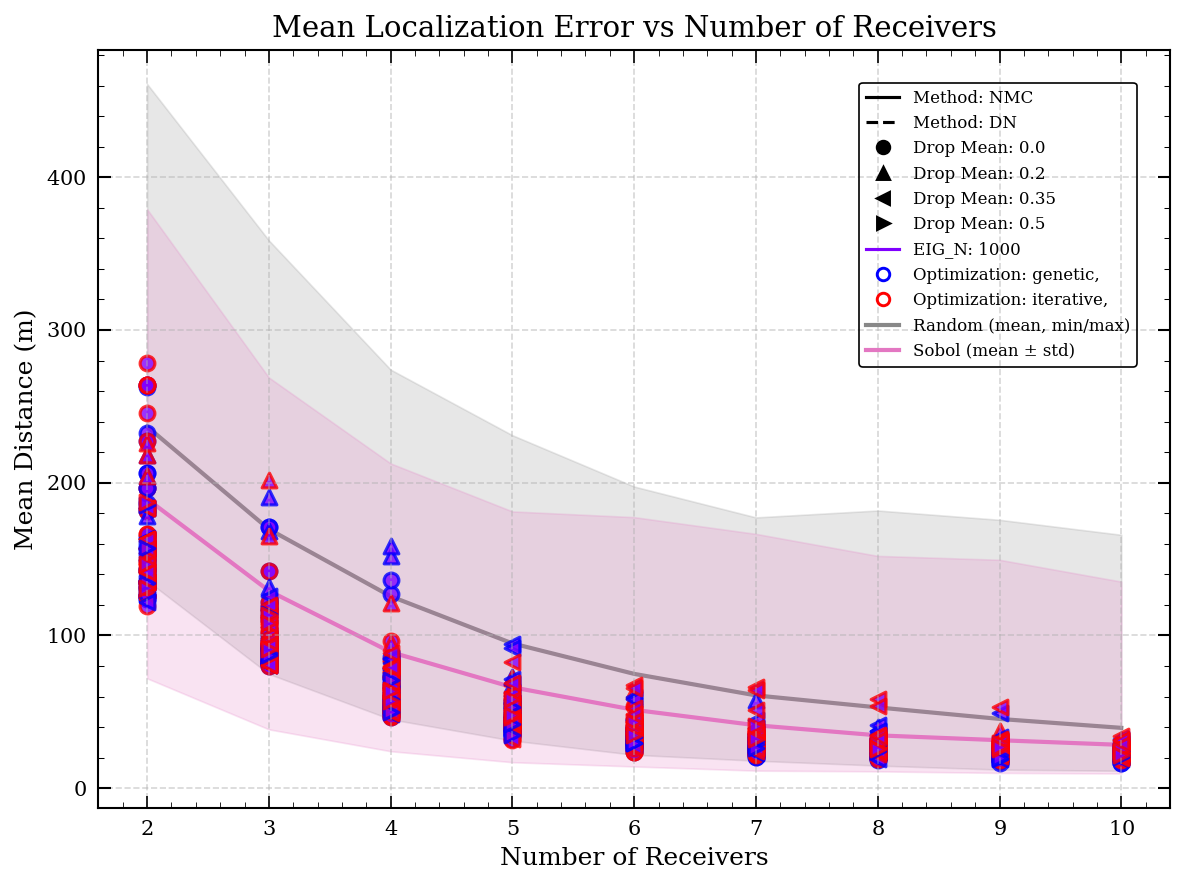

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

metric = 'distance_map'

# Create a figure with a smaller size
fig, ax = plt.subplots(figsize=(8, 6))

# Define markers and line styles
markers = {0.0: 'o', 0.2: '^', 0.35: '<', 0.5: '>'}  # Different markers for drop_mean
linestyles = {'NMC': '-', 'DN': '--'}  # Different line styles for methods

# Define colors for optimization type
opt_colors = {'genetic': 'blue', 'iterative': 'red'}

# Define EIG_N values and create a color gradient using rainbow colormap
eig_n_values = sorted(grouped['EIG_N'].unique())
eig_n_colors = {val: plt.cm.rainbow(i/len(eig_n_values)) for i, val in enumerate(eig_n_values)}

# Plot data for each combination of parameters
for eig_method in sorted(grouped['EIG_method'].unique()):
    for drop_mean in sorted(grouped['drop_mean'].unique()):
        for eig_n in sorted(grouped['EIG_N'].unique()):
            for opt_type in ['genetic', 'iterative']:
                subset = grouped[(grouped['EIG_method'] == eig_method) & 
                                 (grouped['drop_mean'] == drop_mean) &
                                 (grouped['EIG_N'] == eig_n) &
                                 (grouped['optimisation'] == opt_type)]
                
                if not subset.empty:
                    # Sort by N_rec to ensure proper line connections
                    subset = subset.sort_values('N_rec')
                    
                    # Get base color from EIG_N and adjust based on optimization type
                    base_color = eig_n_colors[eig_n]
                    
                    # Plot scatter points with smaller marker size
                    ax.scatter(subset['N_rec'], subset[metric], 
                               color=base_color,
                               marker=markers[drop_mean],
                               s=50, alpha=0.8, edgecolors=opt_colors[opt_type], linewidth=1.5,
                               label=f"{eig_method}, Drop={drop_mean}, EIG_N={eig_n}, {opt_type}")

# --- Add random and sobol design mean ± std lines ---

# Helper function to plot mean ± std for a given dataframe and color
def plot_mean_std(df, label, color, zorder=1):
    # First, group by N_rec and event_index, then take mean over events
    event_means = df.groupby(['N_rec', 'event_index'])[metric].mean().reset_index()
    # Now, group by N_rec and compute mean and std over events
    grouped_stats = event_means.groupby('N_rec')[metric].agg(['mean', 'std']).reset_index()
    ax.plot(grouped_stats['N_rec'], grouped_stats['mean'], color=color, label=label, lw=2, zorder=zorder)
    ax.fill_between(grouped_stats['N_rec'],
                    grouped_stats['mean'] - grouped_stats['std'],
                    grouped_stats['mean'] + grouped_stats['std'],
                    color=color, alpha=0.2, zorder=zorder)

def plot_mean_minmax(df, label, color, zorder=1):
    # First, group by N_rec and event_index, then take mean over events
    event_means = df.groupby(['N_rec', 'event_index'])[metric].mean().reset_index()
    # Now, group by N_rec and compute mean, min, max over events
    grouped_stats = event_means.groupby('N_rec')[metric].agg(['mean', 'min', 'max']).reset_index()
    ax.plot(grouped_stats['N_rec'], grouped_stats['mean'], color=color, label=label, lw=2, zorder=zorder)
    ax.fill_between(grouped_stats['N_rec'],
                    grouped_stats['min'],
                    grouped_stats['max'],
                    color=color, alpha=0.2, zorder=zorder)

# Plot for random designs (mean ± min/max)
if 'random_stats_df' in locals():
    random_stats_df_10 = random_stats_df[random_stats_df['N_rec'] <= 10]
    plot_mean_minmax(random_stats_df_10, 'Random (mean, min/max)', '#888888', zorder=0)

# Plot for sobol designs (mean ± std)
if 'sobol_stats_df' in locals():
    sobol_stats_df_10 = sobol_stats_df[sobol_stats_df['N_rec'] <= 10]
    plot_mean_minmax(sobol_stats_df_10, 'Sobol (mean ± std)', '#e377c2', zorder=0)

# Add labels and title with smaller fontsize
ax.set_title('Mean Localization Error vs Number of Receivers', fontsize=14)
ax.set_xlabel('Number of Receivers', fontsize=12)
ax.set_ylabel('Mean Distance (m)', fontsize=12)

# Create custom legend elements
legend_elements = []

# Method legend (linestyles)
for method, ls in linestyles.items():
    legend_elements.append(Line2D([0], [0], color='black', 
                                 linestyle=ls, lw=1.5,
                                 label=f'Method: {method}'))

# Drop mean legend (markers)
for drop, marker in markers.items():
    legend_elements.append(Line2D([0], [0], marker=marker, color='black', 
                                 linestyle='None', markersize=6, 
                                 label=f'Drop Mean: {drop}'))

# EIG_N legend (colors)
for eig_n, color in eig_n_colors.items():
    legend_elements.append(Line2D([0], [0], color=color, lw=1.5, 
                                 label=f'EIG_N: {eig_n}'))

# Optimization type legend (edge colors)
for opt, color in opt_colors.items():
    legend_elements.append(Line2D([0], [0], markerfacecolor='none', 
                                 markeredgecolor=color, marker='o', 
                                 markersize=6, linestyle='None',
                                 label=f'Optimization: {opt},'))

# Random/Sobol legend
legend_elements.append(Line2D([0], [0], color='#888888', lw=2, label='Random (mean, min/max)'))
legend_elements.append(Line2D([0], [0], color='#e377c2', lw=2, label='Sobol (mean ± std)'))

# Add grid and legend with smaller fontsize
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# Set x-axis to show whole numbers
ax.set_xticks(sorted(grouped['N_rec'].unique()))
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

In [26]:
scen_columns = [
    'study_area', 'model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
    'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N',
]
stat_columns = [
    'mean_x', 'mean_y', 'std_x', 'std_y',
    'distance_mean', 'distance_map',
    'p_posterior', 'posterior_entropy', 'posterior_information',
    'prior_entropy', 'prior_information'
]

def get_summary_stats_event_averaged(summary_df, interest_filters={}, ignore_filters={}, N_min=1, N_max=50):
    """
    Filters the summary_df based on interest and ignore filters, N_rec range,
    and then averages the stat_columns over events (i.e., groups by scen_columns and N_rec).
    """
    df = summary_df.copy()

    # Apply interest filters
    for key, value in interest_filters.items():
        if key in df.columns:
            df = df[df[key] == value]
        else:
            # print(f"Warning: Interest filter key '{key}' not in DataFrame columns.")
            return pd.DataFrame(columns=df.columns) # Return empty df if key not found


    # Apply ignore filters
    for key, value in ignore_filters.items():
        if key in df.columns:
            df = df[df[key] != value]
        else:
            # print(f"Warning: Ignore filter key '{key}' not in DataFrame columns.")
            pass # Or handle as appropriate, e.g. return df or raise error

    # Filter by N_rec
    if 'N_rec' in df.columns:
        df = df[(df['N_rec'] >= N_min) & (df['N_rec'] <= N_max)]
    else:
        # print("Warning: 'N_rec' column not found for N_min/N_max filtering.")
        return pd.DataFrame(columns=df.columns)

    if df.empty:
        return pd.DataFrame(columns=scen_columns + ['N_rec'] + stat_columns)

    # Group by scenario columns and N_rec, then average stat_columns
    # This averages over different events for the same scenario and N_rec
    grouping_cols = [col for col in scen_columns + ['N_rec'] if col in df.columns]
    
    # Ensure all stat_columns exist in df, otherwise, they can't be averaged.
    valid_stat_columns = [col for col in stat_columns if col in df.columns]
    
    if not grouping_cols or not valid_stat_columns:
        # print("Warning: Not enough columns to group or average.")
        return pd.DataFrame(columns=df.columns)


    averaged_df = df.groupby(grouping_cols, as_index=False)[valid_stat_columns].mean()
    
    return averaged_df

def get_summary_stats(summary_df, interest_filters={}, ignore_filters={}, N_min=1, N_max=50):
    """
    Further averages the output of get_summary_stats_event_averaged over N_rec.
    The 'metric' argument is kept for compatibility with example usage but not directly used for column selection here.
    """
    df_event_averaged = get_summary_stats_event_averaged(
        summary_df, interest_filters, ignore_filters, N_min, N_max
    )

    if df_event_averaged.empty:
        return pd.DataFrame(columns=scen_columns + stat_columns)

    # Group by scenario columns (excluding N_rec now), then average stat_columns
    # This averages over different N_rec values for the same scenario
    grouping_cols = [col for col in scen_columns if col in df_event_averaged.columns]
    valid_stat_columns = [col for col in stat_columns if col in df_event_averaged.columns]

    if not grouping_cols or not valid_stat_columns:
        # print("Warning: Not enough columns to group or average after event averaging.")
        return pd.DataFrame(columns=df_event_averaged.columns)
        
    # Create a list of columns to select for grouping, ensuring they exist
    cols_to_group = [col for col in scen_columns if col in df_event_averaged.columns]
    
    # Create a list of columns to average, ensuring they exist
    cols_to_average = [col for col in stat_columns if col in df_event_averaged.columns]

    if not cols_to_group or not cols_to_average:
        return pd.DataFrame(columns=scen_columns + stat_columns)


    # Perform the grouping and averaging
    # Add check for empty df_event_averaged before groupby
    if df_event_averaged.empty:
        return pd.DataFrame(columns=cols_to_group + cols_to_average)
        
    averaged_df = df_event_averaged.groupby(cols_to_group, as_index=False)[cols_to_average].mean()
    
    return averaged_df

In [27]:
grouped[
    (grouped['velocity_model'] == 'gradient') &
    (grouped['EIG_method'] == 'NMC') &
    (grouped['EIG_N'] == 1000) &
    (grouped['optimisation'] =='genetic')
].groupby(scen_columns).mean().reset_index()

,study_area,model_prior,velocity_model,vel_sigma,noise_correlation,drop_mean,drop_gradient,optimisation,EIG_method,EIG_N,...,mean_y,std_x,std_y,distance_mean,distance_map,p_posterior,posterior_entropy,posterior_information,prior_entropy,prior_information
0,shoulder,uniform,gradient,0.005,100,0.00,0,genetic,NMC,1000,...,1420.259601,92.764544,47.048929,80.866987,64.214544,0.008514,10.337373,-10.337373,12.376237,-12.376237
1,shoulder,uniform,gradient,0.005,100,0.35,-30,genetic,NMC,1000,...,1422.637212,93.088773,52.748139,95.566805,68.825155,0.007236,10.484471,-10.484471,12.376237,-12.376237
2,shoulder,uniform,gradient,0.010,100,0.00,0,genetic,NMC,1000,...,1418.463251,90.964681,46.969552,79.429270,57.580305,0.008616,10.323088,-10.323088,12.376237,-12.376237
3,shoulder,uniform,gradient,0.010,100,0.35,-30,genetic,NMC,1000,...,1419.850450,92.608249,52.184451,94.923837,67.021345,0.008074,10.443285,-10.443285,12.376237,-12.376237
4,shoulder,uniform,gradient,0.050,0,0.00,0,genetic,NMC,1000,...,1420.527281,80.079217,45.452207,74.129265,48.333837,0.008862,10.236460,-10.236460,12.376237,-12.376237
5,shoulder,uniform,gradient,0.050,0,0.35,-30,genetic,NMC,1000,...,1420.327076,78.022453,49.396396,75.189915,54.307762,0.008798,10.252257,-10.252257,12.376237,-12.376237
6,shoulder,uniform,gradient,0.050,50,0.00,0,genetic,NMC,1000,...,1421.498759,76.116329,47.115160,71.172900,49.382295,0.009112,10.220189,-10.220189,12.376237,-12.376237
7,shoulder,uniform,gradient,0.050,50,0.35,-30,genetic,NMC,1000,...,1420.666775,79.061645,51.469689,79.221851,54.351274,0.008634,10.291950,-10.291950,12.376237,-12.376237
8,shoulder,uniform,gradient,0.050,100,0.00,0,genetic,NMC,1000,...,1420.222097,77.474819,46.455149,72.419430,50.738316,0.009027,10.223872,-10.223872,12.376237,-12.376237
9,shoulder,uniform,gradient,0.050,100,0.20,-100,genetic,NMC,1000,...,1422.153494,92.586778,47.093461,83.215012,92.728605,0.009193,10.350771,-10.350771,12.376237,-12.376237


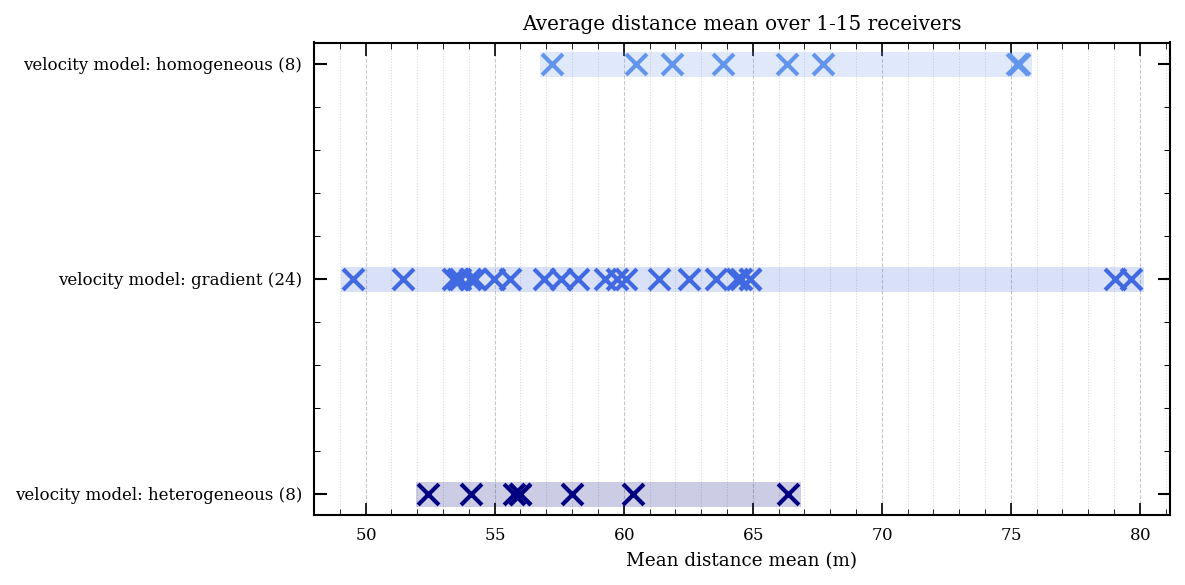

In [28]:
scenarios = dict(
    vel_homogeneous = dict(
        name='velocity model: homogeneous',
        interest_filters=dict(velocity_model='homogeneous', EIG_method='NMC', EIG_N=1000,
        # vel_sigma=0.05, noise_correlation=100, drop_mean=0.0,
         optimisation='genetic'))
    ,
    vel_gradient = dict(
        name='velocity model: gradient',
        interest_filters=dict(velocity_model='gradient', EIG_method='NMC', EIG_N=1000,
        # vel_sigma=0.05, noise_correlation=100, drop_mean=0.0,
         optimisation='genetic'))
    ,
    vel_heterogeneous = dict(
        name='velocity model: heterogeneous',
        interest_filters=dict(velocity_model='heterogeneous', EIG_method='NMC', EIG_N=1000,
        # vel_sigma=0.05, noise_correlation=100, drop_mean=0.0,
         optimisation='genetic'))
)

color_list = [
    'cornflowerblue', 'royalblue', 'navy',
    'forestgreen', 'limegreen', 'darkgreen',
    'darkorange', 'orangered',
]


# Plotting parameters from the example
N_rec_min = 1
N_rec_max = 15
metric_to_plot = 'distance_mean'

plot_data_collections = []
plot_labels = []

# Iterate through the defined scenarios
for scenario_key, scenario_config in scenarios.items():
    current_interest_filters = scenario_config.get('interest_filters', {})
    current_ignore_filters = scenario_config.get('ignore_filters', {})

    # Use get_summary_stats to filter and average data for the scenario
    # get_summary_stats groups by scen_columns and calculates the mean of stat_columns
    scenario_summary_df = get_summary_stats(
        summary_df=summary_statistics,
        interest_filters=current_interest_filters,
        ignore_filters=current_ignore_filters,
        N_min=N_rec_min,
        N_max=N_rec_max,
    )
    
    # The metric_to_plot should be one of the stat_columns
    if not scenario_summary_df.empty and metric_to_plot in scenario_summary_df.columns:
        plot_data_collections.append(scenario_summary_df[metric_to_plot])
        # Use the 'name' from scenario_config for labels, and replace underscores
        label_name = scenario_config.get('name', scenario_key).replace('_', ' ')
        # Add count of data points like in the example (len(stat))
        plot_labels.append(f"{label_name} ({len(scenario_summary_df[metric_to_plot])})")
    else:
        label_name = scenario_config.get('name', scenario_key).replace('_', ' ')
        plot_data_collections.append(pd.Series(dtype='float64')) 
        plot_labels.append(f"{label_name} (No data)")

# Create the plot, inspired by the example
if plot_labels: # Check if there are any labels (means scenarios were processed)
    fig, ax = plt.subplots(figsize=(8, 4)) # Matches example figsize

    for i, data_series in enumerate(plot_data_collections):
        if not data_series.empty:
            # Plot range bar (min to max of the means for this scenario group)
            ax.plot([data_series.min(), data_series.max()], [i, i], 
                    color=color_list[i % len(color_list)], 
                    linewidth=12.0, alpha=0.2)
            
            # Plot individual mean data points (each point is a mean for a sub-configuration)
            ax.scatter(data_series, np.full(len(data_series), i), 
                       marker='x', color=color_list[i % len(color_list)], 
                       s=100, alpha=1.0, zorder=10, linewidth=2.0)
        # If data_series is empty, nothing is plotted for this row; the label indicates "No data"

    ax.set_yticks(np.arange(len(plot_labels)))
    ax.set_yticklabels(plot_labels)

    ax.set_xlabel(f'Mean {metric_to_plot.replace("_", " ")} (m)')
    # Title similar to the example
    ax.set_title(f'Average {metric_to_plot.replace("_", " ")} over {N_rec_min}-{N_rec_max} receivers')

    ax.invert_yaxis() # Common for this type of comparison plot
    ax.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.minorticks_on()
    ax.grid(True, axis='x', linestyle=':', linewidth=0.5, which='minor', alpha=0.5)
        
    plt.tight_layout()
    plt.show()
else:
    print("No scenarios processed or no data found for the defined scenarios.")

In [29]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(grouped)

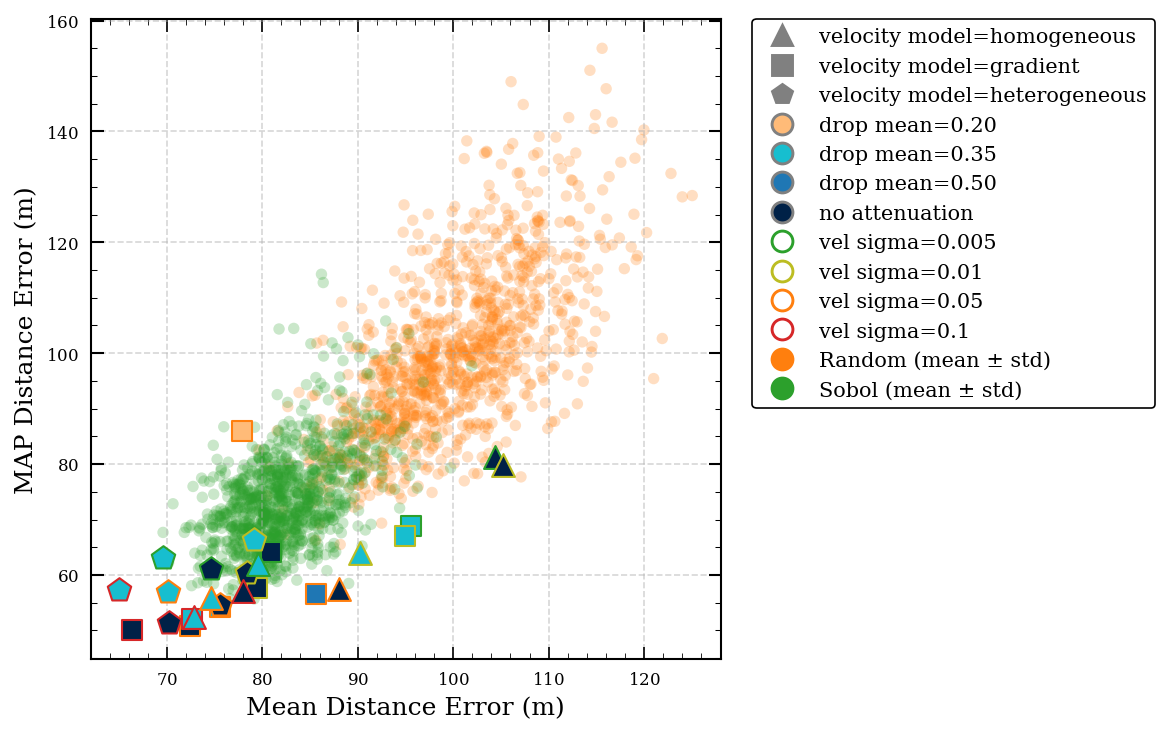

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

# Style dictionaries
velocity_model_marker = {
    'homogeneous': '^', 
    'gradient': 's',
    'heterogeneous': 'p'
}

marker_sizes = {
    'homogeneous': 120,
    'gradient': 100,
    'heterogeneous': 140
}

drop_mean_colors = {
    0.2: '#ffbb78',    # orange-tinted light (for future extension)
    0.35: '#17becf',   # cyan/teal
    0.5: '#1f77b4',    # medium blue
    0.0: '#002147',    # darkest blue (no attenuation)
}

vel_sigma_edge = {
    0.005: '#2ca02c',   # green
    0.01: '#bcbd22',    # olive
    0.05: '#ff7f0e',    # orange
    0.1: '#d62728',     # red
}

# Filter data
filtered = grouped[
    (grouped['EIG_method'] == 'NMC') &
    (grouped['EIG_N'] == 1000) &
    (grouped['N_rec'] <= 10) &
    ((grouped['drop_gradient'] == 0.0) | (grouped['drop_gradient'] == -30.0)) &
    (grouped['noise_correlation'] == 100) &
    # (grouped['vel_sigma'] == 0.05 )&
    (grouped['optimisation'] == 'genetic')
]

# Allow user to define which quantities to plot and their labels
x_quantity = 'distance_mean'
y_quantity = 'distance_map'
quantity_labels = {
    'distance_mean': 'Mean Distance Error (m)',
    'distance_map': 'MAP Distance Error (m)',
}

# Take mean over all receivers for each combination of velocity_model, vel_sigma, and drop_mean
filtered = (
    filtered.groupby(['velocity_model', 'vel_sigma', 'drop_mean'], as_index=False)
    .agg({x_quantity: 'mean', y_quantity: 'mean'})
)

for _, row in filtered.iterrows():
    marker = velocity_model_marker.get(row['velocity_model'], 'o')
    marker_size = marker_sizes.get(row['velocity_model'], 100)
    facecolor = drop_mean_colors.get(round(row['drop_mean'], 2), 'gray')
    edgecolor = vel_sigma_edge.get(row['vel_sigma'], 'black')
    ax.scatter(
        row[x_quantity], row[y_quantity],
        marker=marker, facecolor=facecolor, edgecolor=edgecolor, linewidth=1, alpha=1.0, s=marker_size, zorder=10
    )

# --- Add random and sobol benchmarks with spread ---

# Helper: aggregate over receivers for each method
def aggregate_benchmark_meanstd(df, method_name):
    # First average over events for each N_rec
    agg_by_nrec = (
        df[df['N_rec'] <= 10]
        .groupby('N_rec')
        .agg(
            x_mean=(x_quantity, 'mean'),
            y_mean=(y_quantity, 'mean'),
            x_std=(x_quantity, 'std'),
            y_std=(y_quantity, 'std')
        )
        .reset_index()
    )
    # Then aggregate over N_rec
    agg_result = {
        'x_mean': agg_by_nrec['x_mean'].mean(),
        'y_mean': agg_by_nrec['y_mean'].mean(),
        'x_std': agg_by_nrec['x_mean'].std(),
        'y_std': agg_by_nrec['y_mean'].std(),
        'method': method_name
    }
    return agg_result

# # Random
# if 'random_stats_df' in locals():
#     random_agg = aggregate_benchmark_meanstd(random_stats_df, 'random')
#     ax.errorbar(
#         random_agg['x_mean'], random_agg['y_mean'],
#         xerr=random_agg['x_std'], yerr=random_agg['y_std'],
#         fmt='o', color='tab:orange', label='Random (mean ± std)', alpha=0.8, capsize=4, markersize=8, zorder=10
#     )

# # Sobol
# if 'sobol_stats_df' in locals():
#     sobol_agg = aggregate_benchmark_meanstd(sobol_stats_df, 'sobol')
#     ax.errorbar(
#         sobol_agg['x_mean'], sobol_agg['y_mean'],
#         xerr=sobol_agg['x_std'], yerr=sobol_agg['y_std'],
#         fmt='D', color='tab:green', label='Sobol (mean ± std)', alpha=0.8, capsize=4, markersize=8, zorder=10
#     )

# --- Visualize distribution of random and sobol benchmarks as scatter clouds ---

# Helper: aggregate over events and N_rec for each design_index
def get_design_scatter(df, x_col, y_col):
    # Group by design_index, average over events and N_rec
    grouped = (
        df.groupby('design_index')
        .agg(
            x_mean=(x_col, 'mean'),
            y_mean=(y_col, 'mean')
        )
        .reset_index()
    )
    return grouped

# Plot random benchmark scatter cloud
if 'random_stats_df' in locals():
    random_scatter = get_design_scatter(random_stats_df[random_stats_df['N_rec'] <= 10], x_quantity, y_quantity)
    ax.scatter(
        random_scatter['x_mean'], random_scatter['y_mean'], edgecolors='none',
        color='tab:orange', alpha=0.25, s=30, label='_nolegend_', zorder=1
    )

# Plot sobol benchmark scatter cloud
if 'sobol_stats_df' in locals():
    sobol_scatter = get_design_scatter(sobol_stats_df[sobol_stats_df['N_rec'] <= 10], x_quantity, y_quantity)
    ax.scatter(
        sobol_scatter['x_mean'], sobol_scatter['y_mean'], edgecolors='none',
        color='tab:green', alpha=0.25, s=30, label='_nolegend_', zorder=1
    )


ax.set_xlabel(quantity_labels.get(x_quantity, x_quantity), fontsize=12)
ax.set_ylabel(quantity_labels.get(y_quantity, y_quantity), fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

# Custom legend
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

legend_elements = []

# Velocity model markers
for vmodel, marker in velocity_model_marker.items():
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='w', label=f'velocity model={vmodel.replace("_", " ")}',
               markerfacecolor='gray', markeredgecolor='gray', markersize=10)
    )

# Drop mean colors
for drop, color in drop_mean_colors.items():
    if drop == 0.0:
        label = 'no attenuation'
    else:
        label = f'drop mean={drop:.2f}'
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', label=label.replace("_", " "),
               markerfacecolor=color, markeredgecolor='gray', markersize=10)
    )

# vel_sigma edge colors
for sigma, edgecolor in vel_sigma_edge.items():
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', label=f'vel sigma={sigma}'.replace("_", " "),
               markerfacecolor='white', markeredgecolor=edgecolor, markersize=10)
    )

# Add random/sobol legend
legend_elements.append(Line2D([0], [0], marker='o', color='tab:orange', label='Random (mean ± std)', markersize=10, linestyle='None'))
legend_elements.append(Line2D([0], [0], marker='o', color='tab:green', label='Sobol (mean ± std)', markersize=10, linestyle='None'))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, borderaxespad=0.)

plt.tight_layout()
plt.show()

* Heterogeneous velocity model necessary to outperform random design consistently